# 04 · Inverse Kinematics

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/boelnasr/ManipulaPy/blob/notebooks/tutorials/notebooks/04_inverse_kinematics.ipynb)

> **ManipulaPy teaching course — notebook 4 of 11.** Running robot: Franka Panda.

Forward kinematics (notebook 02) sends joint angles to a pose; the Jacobian (notebook 03) sends joint *rates* to a twist. **Inverse kinematics** runs the first map backwards: given a desired end-effector pose $T_d$, find joint angles $\theta$ with $T(\theta)=T_d$. Unlike FK there is no closed-form answer for a general arm — we solve it **iteratively**, and the Jacobian is what makes each step. This notebook builds the **damped least-squares** solver by hand, checks it against ManipulaPy's, and uses the Panda's redundancy to land *a* solution among many.

### Running on Colab or another cloud platform?

The next cell bootstraps the environment on Google Colab. It is a **no-op when you run locally** from a clone of the repo.

In [1]:
# Cloud bootstrap (no-op when running locally from the repo).
import sys
if "google.colab" in sys.modules:
    !git clone -q https://github.com/boelnasr/ManipulaPy.git
    %cd ManipulaPy/notebooks
    !pip install -q -e ..
    print("Colab setup complete.")

In [2]:
import os, sys
sys.path.insert(0, os.path.join(os.getcwd(), "_shared"))
from tikz import render_tikz_file, setup_pgf, embed_pgf_fig
import numpy as np
from helpers import load_panda, HOME, N_JOINTS, joint_limits
from ManipulaPy.utils import MatrixLog6, se3ToVec, TransInv
np.set_printoptions(precision=4, suppress=True)
np.random.seed(0)                       # reproducible random seeds/targets

sm, dyn = load_panda()
# The solver clips against sm.joint_limits, which ships with 8 entries (the URDF's
# 7 arm joints + the gripper finger). This course works in the 7 actuated joints,
# so install the 7-entry limit set -- IK, FK and the Jacobian are then all 7-DOF.
sm.joint_limits = joint_limits()
print("Panda loaded |", N_JOINTS, "actuated joints | joint_limits:", len(sm.joint_limits))

🤖 ManipulaPy v1.3.2.post1 loaded (lazy imports enabled)
   💡 Use ManipulaPy.check_dependencies() to see available features
Panda loaded | 7 actuated joints | joint_limits: 7


pybullet build time: Jan 29 2025 23:16:28


## 1. The inverse problem and Newton–Raphson

We want $\theta$ such that $T(\theta)=T_d$. Writing the pose error as a **body twist** — the screw that carries the current pose $T(\theta)$ onto the target — turns IK into **root finding**:

$$F(\theta)=\log\!\big(T(\theta)^{-1}T_d\big)^{\vee}=\mathcal{V}_b(\theta)\;\stackrel{!}{=}\;0.$$

**The scalar idea.** Newton–Raphson solves a one-dimensional equation $f(x)=0$ by repeatedly following the *tangent line* to where it crosses zero:

$$x_{k+1}=x_k-\frac{f(x_k)}{f'(x_k)}.$$

Each step replaces the curve with its linear approximation at $x_k$ and jumps to that line's root. Near a simple root the error roughly **squares** every step — quadratic convergence.

**Lifting it to a robot.** Now $\theta$ and the residual $F$ are vectors, so the scalar derivative $f'$ becomes a matrix — and that matrix is exactly the **body Jacobian** $J_b(\theta)$ from notebook 03 (to first order a joint step $\Delta\theta$ changes the error twist by $J_b\,\Delta\theta$). The scalar reciprocal $1/f'$ becomes the Jacobian inverse, giving the **Newton–Raphson step for inverse kinematics**:

$$\theta_{k+1}=\theta_k+J_b(\theta_k)^{-1}\,\mathcal{V}_b(\theta_k),\qquad \mathcal{V}_b=\log\!\big(T(\theta_k)^{-1}T_d\big)^{\vee}.$$

That is the whole algorithm: measure the pose error as a twist, solve a linear system for the joint correction, step, repeat.

**Two practical fixes.** For the 7-DOF Panda $J_b$ is $6\times7$ — not square, so it has no inverse. We use the Moore–Penrose **pseudoinverse** $J_b^{\dagger}=J_b^{\top}(J_bJ_b^{\top})^{-1}$, which takes the minimum-norm joint step (the **Gauss–Newton** variant). And near a singularity $J_bJ_b^{\top}$ becomes ill-conditioned and the step explodes, so we **damp** it (Levenberg–Marquardt):

$$\Delta\theta=J_b^{\top}\big(J_bJ_b^{\top}+\lambda^2 I\big)^{-1}\mathcal{V}_b.$$

With $\lambda=0$ this is the undamped Newton–Raphson step above; a positive $\lambda$ trades raw speed for stability — a tradeoff we measure in Section 3. Notice every ingredient is something earlier notebooks already built: `forward_kinematics`, `MatrixLog6` (notebook 01), and the body Jacobian (notebook 03).

The picture below is the scalar construction on $f(x)=x^2-2$: from a guess $x_0$, follow the **tangent** down to where it meets the axis — that intercept is $x_1$ — then repeat from the curve above $x_1$. The iterates race to the root $x^{*}=\sqrt{2}$, and the same geometry, with the Jacobian as the slope, is what the robot solver runs below.

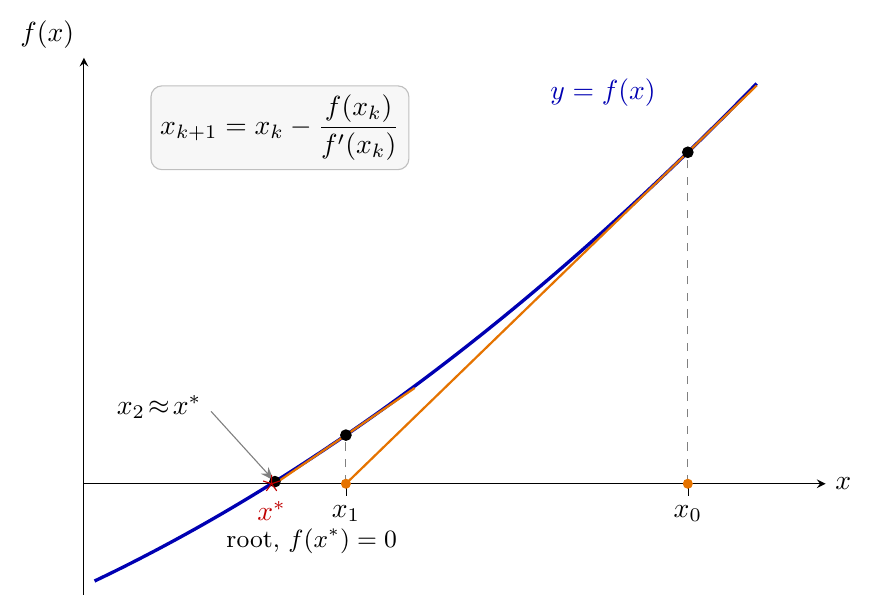

In [3]:
render_tikz_file("_figures/src/newton_raphson.tex", name="newton_raphson")

## 2. Newton–Raphson by hand

We pick a **reachable** target by running FK on a known configuration `q_target` (so a solution provably exists), then iterate the step above from a different starting guess. One routine covers both methods: `lam=0` is pure Newton–Raphson (the bare pseudoinverse step), and a small `lam` is the damped variant. We record the twist-error norm at each step for the convergence plot in Section 4.

In [4]:
q_target = np.array([0.6, -0.5, 0.4, -1.8, 0.3, 1.5, -0.2])   # a known config
T_d = sm.forward_kinematics(q_target, frame='space')           # => a reachable pose

def newton_ik(T_target, q0, lam=0.0, max_iters=60, tol=1e-8):
    '''Newton-Raphson IK in the body frame; lam>0 adds Levenberg-Marquardt
    damping. Returns (theta, residual_history).'''
    q = np.array(q0, float)
    history = []
    for _ in range(max_iters):
        Tb = sm.forward_kinematics(q, frame='space')
        Vb = se3ToVec(MatrixLog6(TransInv(Tb) @ T_target))     # body-frame twist error
        history.append(np.linalg.norm(Vb))
        if history[-1] < tol:
            break
        Jb = sm.jacobian(q, frame='body')                      # the 'derivative' of F
        dq = Jb.T @ np.linalg.solve(Jb @ Jb.T + lam**2 * np.eye(6), Vb)
        q = q + dq                                             # the Newton step
    return q, history

theta_nr, hist_nr = newton_ik(T_d, HOME, lam=0.0)              # pure Newton-Raphson
theta_hand, hist = newton_ik(T_d, HOME, lam=0.05)             # damped variant
T_hand = sm.forward_kinematics(theta_hand, frame='space')
print("Newton-Raphson (lam=0):  %2d iterations, final twist error %.2e"
      % (len(hist_nr), hist_nr[-1]))
print("damped         (lam=0.05): %2d iterations, final twist error %.2e"
      % (len(hist), hist[-1]))
assert np.allclose(T_hand[:3, 3], T_d[:3, 3], atol=1e-4)        # position recovered
assert np.allclose(T_hand[:3, :3], T_d[:3, :3], atol=1e-4)      # orientation recovered
assert np.allclose(sm.forward_kinematics(theta_nr)[:3, 3], T_d[:3, 3], atol=1e-4)

Newton-Raphson (lam=0):   7 iterations, final twist error 1.38e-13
damped         (lam=0.05): 10 iterations, final twist error 1.49e-09


## 3. The library solver and the damping knob

ManipulaPy packages the same idea — plus joint-limit projection, an SVD-robust solve, adaptive damping and stagnation recovery — in `iterative_inverse_kinematics(T_desired, thetalist0)`, which returns `(theta, success, iterations)`. We recover a target from a perturbed seed, then sweep the `damping` parameter to see its cost.

In [5]:
seed = HOME + 0.2                                   # start 0.2 rad off every joint
theta, ok, iters = sm.iterative_inverse_kinematics(T_d, seed, max_iterations=2000)
T_sol = sm.forward_kinematics(theta, frame='space')
print("library IK: success=%s  iterations=%d  position error=%.2e m"
      % (ok, iters, np.linalg.norm(T_sol[:3, 3] - T_d[:3, 3])))
assert ok and np.allclose(T_sol[:3, 3], T_d[:3, 3], atol=1e-3)

# The damping lambda trades stability for speed: small lambda -> near-Newton, fast;
# large lambda -> heavily regularised, stable near singularities but slow.
print("\ndamping   iterations")
for lam in [5e-3, 2e-2, 1e-1, 3e-1]:
    _, ok_l, it_l = sm.iterative_inverse_kinematics(
        T_d, seed, damping=lam, max_iterations=3000)
    print("  %.0e      %3d%s" % (lam, it_l, "" if ok_l else "  (no convergence)"))

library IK: success=True  iterations=14  position error=5.45e-08 m

damping   iterations
  5e-03       14
  2e-02       14
  1e-01       17
  3e-01       41


## 4. Convergence

Newton–Raphson converges **quadratically** near the solution — the error roughly squares each step. Plotting both by-hand runs on a log axis shows the characteristic cliff, and that the undamped step ($\lambda=0$) is a step or two quicker *here*: at this well-conditioned pose the damping is insurance we don't need. Near a singularity that same insurance is what stops the curve from blowing up.

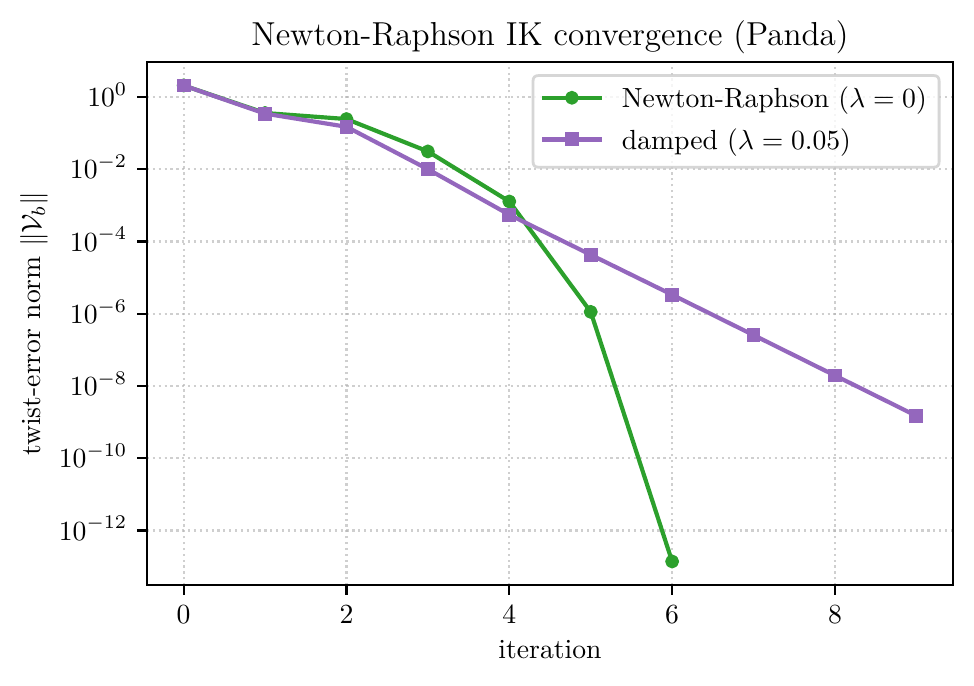

In [6]:
plt = setup_pgf()
fig, ax = plt.subplots(figsize=(5.2, 3.4))
ax.semilogy(range(len(hist_nr)), hist_nr, '-o', color='tab:green', ms=4,
            label='Newton-Raphson ($\\lambda=0$)')
ax.semilogy(range(len(hist)), hist, '-s', color='tab:purple', ms=4,
            label='damped ($\\lambda=0.05$)')
ax.set_xlabel('iteration'); ax.set_ylabel('twist-error norm $\\|\\mathcal{V}_b\\|$')
ax.set_title('Newton-Raphson IK convergence (Panda)')
ax.legend(); ax.grid(True, which='both', ls=':', alpha=0.6)
embed_pgf_fig(fig, name="ik_convergence")

## 5. A wider family of IK algorithms

Newton–Raphson and its damped cousin are the **Jacobian-based iterative** branch, but they are one part of a larger family. The main approaches:

- **Jacobian transpose** — $\Delta\theta=\alpha\,J_b^{\top}\mathcal{V}_b$. Replaces the inverse with a plain transpose: no linear solve, so each step is cheap and it *never* blows up at a singularity. The cost is slow, gradient-descent-like convergence (many steps).
- **Pseudoinverse (Gauss–Newton)** — $\Delta\theta=J_b^{\dagger}\mathcal{V}_b$. The true Newton step from Section 1: fast (quadratic) but fragile near singularities.
- **Damped least squares (Levenberg–Marquardt)** — $\Delta\theta=J_b^{\top}(J_bJ_b^{\top}+\lambda^2I)^{-1}\mathcal{V}_b$. Interpolates between the two ($\lambda\to0$ is Gauss–Newton; large $\lambda$ behaves like a scaled transpose step). This is `iterative_inverse_kinematics`.
- **Optimization-based** — recast IK as *minimise* $\|\text{pose error}\|^2$ *subject to joint limits* and hand it to a numerical optimiser (SQP, BFGS, …). Naturally handles joint-limit and collision constraints and escapes local minima, at a higher per-step cost. This is what `trac_ik` runs.
- **Analytical / closed-form** — for arms with special geometry (a spherical wrist, Pieper's condition) the equations solve exactly and instantly, returning *every* solution. No seed, no iteration — but it must be derived per robot, and the Panda's offset wrist has no simple closed form.
- **Heuristic / geometric** — Cyclic Coordinate Descent (CCD) and FABRIK nudge one or two joints at a time toward the goal; simple and fast, popular in animation and for highly redundant chains, but weaker on orientation accuracy.
- **Learned** — neural models (e.g. normalising-flow IK) approximate the inverse map from data, trading exactness for speed and full solution-set coverage.

ManipulaPy implements the first two families. We have used the Jacobian-inverse methods — below we run the **transpose** and the **optimisation** (TRAC-IK) approaches on the same target to feel the difference.

In [7]:
# Jacobian TRANSPOSE: swap the inverse for a plain transpose. No linear solve, so
# each step is cheap and never blows up at a singularity -- but it takes many more
# steps. The scalar alpha is the error-minimising step length along the J^T V_b ray.
def jt_ik(T_target, q0, max_iters=1000, tol=1e-4):
    '''Jacobian-transpose IK in the body frame. Returns (theta, residual_history).'''
    q = np.array(q0, float)
    history = []
    for _ in range(max_iters):
        Tb = sm.forward_kinematics(q, frame='space')
        Vb = se3ToVec(MatrixLog6(TransInv(Tb) @ T_target))
        history.append(np.linalg.norm(Vb))
        if history[-1] < tol:
            break
        Jb = sm.jacobian(q, frame='body')
        JJtV = Jb @ Jb.T @ Vb
        alpha = float(Vb @ JJtV / (JJtV @ JJtV + 1e-12))    # optimal step length
        q = q + alpha * (Jb.T @ Vb)                         # transpose step, no inverse
    return q, history

theta_jt, hist_jt = jt_ik(T_d, HOME)
T_jt = sm.forward_kinematics(theta_jt, frame='space')
print("Jacobian transpose: %d iterations (vs %d for Newton-Raphson) for the same pose"
      % (len(hist_jt), len(hist_nr)))
assert np.allclose(T_jt[:3, 3], T_d[:3, 3], atol=1e-3)      # reaches the target, slowly

Jacobian transpose: 189 iterations (vs 7 for Newton-Raphson) for the same pose


### Optimization-based: TRAC-IK

`trac_ik` is modelled on the TRAC-IK solver (Beeson & Ames, 2015), whose insight was that the classic Jacobian solvers have a blind spot: when the solution lies against a **joint limit**, an unconstrained Newton/DLS step keeps trying to push past the bound and stalls. TRAC-IK runs **two solvers concurrently** and returns whichever finishes first:

- a **damped-least-squares** solver — the fast, local method we built above; and
- a **Sequential Quadratic Programming** optimiser that recasts IK as *minimise* $f(\theta)=\|e(\theta)\|^2$ subject to the joint limits as hard **bounds**, with the analytic gradient $\nabla f=2J^{\top}e$ (SLSQP). Being bounds-aware it handles limit-constrained poses the Jacobian step trips on, and being an optimiser it can escape local minima.

ManipulaPy's implementation adds **diverse initial guesses** (a workspace heuristic, the joint-limit midpoint, and random restarts), runs sequentially by default (parallel optional), and — crucially — takes a hard **`timeout`**. It is an *anytime* solver: when the clock runs out it returns the best configuration found so far. With a `theta0` warm start it suits real-time control loops, where the previous step's solution seeds the next.

It returns `(theta, success, solve_time_seconds)`:

In [8]:
theta_tr, ok_tr, secs = sm.trac_ik(T_d, theta0=HOME, timeout=0.2)
T_tr = sm.forward_kinematics(theta_tr, frame='space')
print("trac_ik: success=%s in %.1f ms, position error = %.2e m"
      % (ok_tr, secs * 1000, np.linalg.norm(T_tr[:3, 3] - T_d[:3, 3])))
assert ok_tr

trac_ik: success=True in 8.4 ms, position error = 6.16e-06 m


### Success vs latency: a solver tradeoff

The design goal of `trac_ik` is **bounded latency**, not maximum success rate — and the clearest way to see what that buys is to put the solvers on the same targets and measure *both* axes. We solve a batch of reachable poses (FK of random in-limit configs, so a solution always exists) with three solvers and record success rate and median solve time.

*(The exhaustive multi-start solver is seconds-slow, so this runs on a small batch and takes about a minute.)*

In [9]:
import time, warnings
# scipy's SLSQP prints a benign out-of-bounds notice on some steps; quiet it.
warnings.filterwarnings("ignore", message="Values in x were outside bounds")
lims = np.array(joint_limits())

def solve_time(fn):
    t0 = time.perf_counter(); out = fn(); return out, (time.perf_counter() - t0) * 1000

np.random.seed(7)
bench_targets = [sm.forward_kinematics(np.random.uniform(lims[:, 0], lims[:, 1]),
                                       frame='space') for _ in range(12)]
solvers = {
    'iterative\n(1 seed)':   lambda T: sm.iterative_inverse_kinematics(T, HOME, max_iterations=500),
    'robust\n(multi-start)': lambda T: sm.robust_inverse_kinematics(T),
    'trac_ik\n(DLS+SQP)':    lambda T: sm.trac_ik(T, theta0=HOME, timeout=0.2, num_restarts=5),
}
bench = {}
for name, fn in solvers.items():
    succ, times = 0, []
    for T in bench_targets:
        out, ms = solve_time(lambda: fn(T))
        succ += bool(out[1]); times.append(ms)
    bench[name] = (100 * succ / len(bench_targets), float(np.median(times)))
    print('%-22s success %3.0f%%  median %8.1f ms'
          % (name.replace('\n', ' '), bench[name][0], bench[name][1]))

iterative (1 seed)     success  92%  median     14.1 ms


robust (multi-start)   success 100%  median   3556.0 ms


trac_ik (DLS+SQP)      success  92%  median     30.1 ms


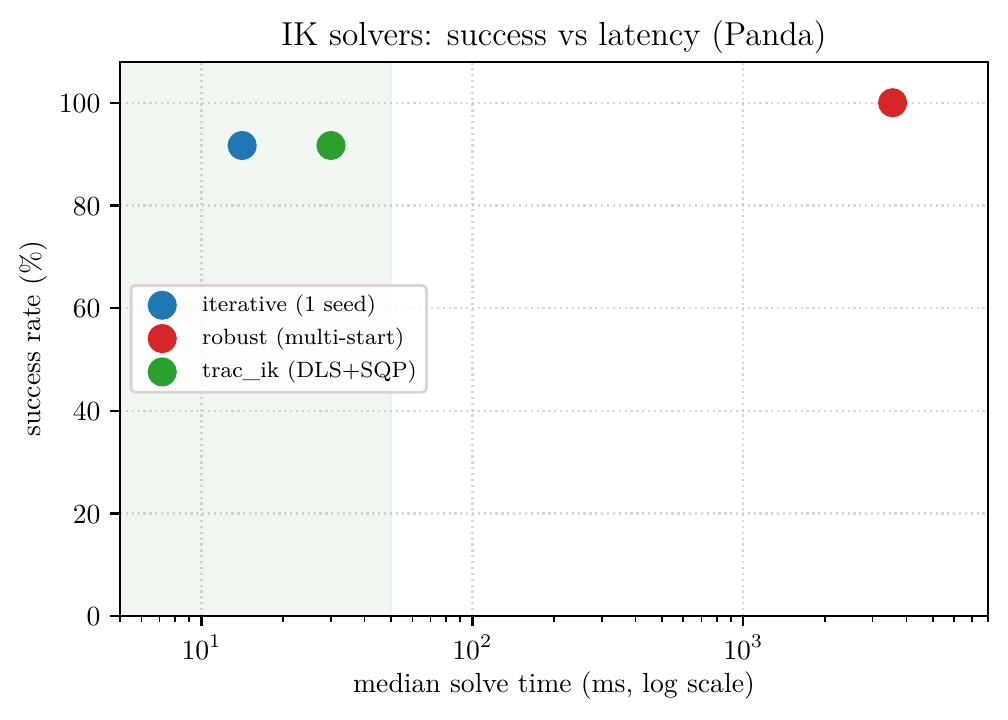

In [10]:
plt = setup_pgf()
fig, ax = plt.subplots(figsize=(5.6, 3.6))
colors = {'iterative\n(1 seed)': 'tab:blue', 'robust\n(multi-start)': 'tab:red',
          'trac_ik\n(DLS+SQP)': 'tab:green'}
for name, (succ, med) in bench.items():
    ax.scatter(med, succ, s=90, color=colors[name], label=name.replace('\n', ' '), zorder=3)
ax.axvspan(0, 50, color='green', alpha=0.06)                 # real-time region
ax.set_xscale('log'); ax.set_xlim(5, 8000); ax.set_ylim(0, 108)
ax.set_xlabel('median solve time (ms, log scale)'); ax.set_ylabel('success rate (%)')
ax.set_title('IK solvers: success vs latency (Panda)')
ax.legend(loc='center left', fontsize=8); ax.grid(True, ls=':', alpha=0.5)
embed_pgf_fig(fig, name="ik_solver_tradeoff")

The three solvers trace out a **tradeoff**, not a ranking:

- **single-shot DLS** — fast (~10 ms), but a single seed misses a fraction of poses;
- **multi-start (`robust`)** — approaches 100%, but spends **seconds**, unusable inside a control loop;
- **`trac_ik`** — lives in the real-time corner (tens of ms, capped by its `timeout`), accepting that within that budget it won't crack every pose.

Raising `trac_ik`'s `timeout` or `num_restarts` moves it up and to the right — more success, more latency. Its latency *profile* over many targets is what a controller has to budget for: most solves land fast, with a tail at the right edge where it spent the whole timeout on a pose it could not reach and returned its best attempt.

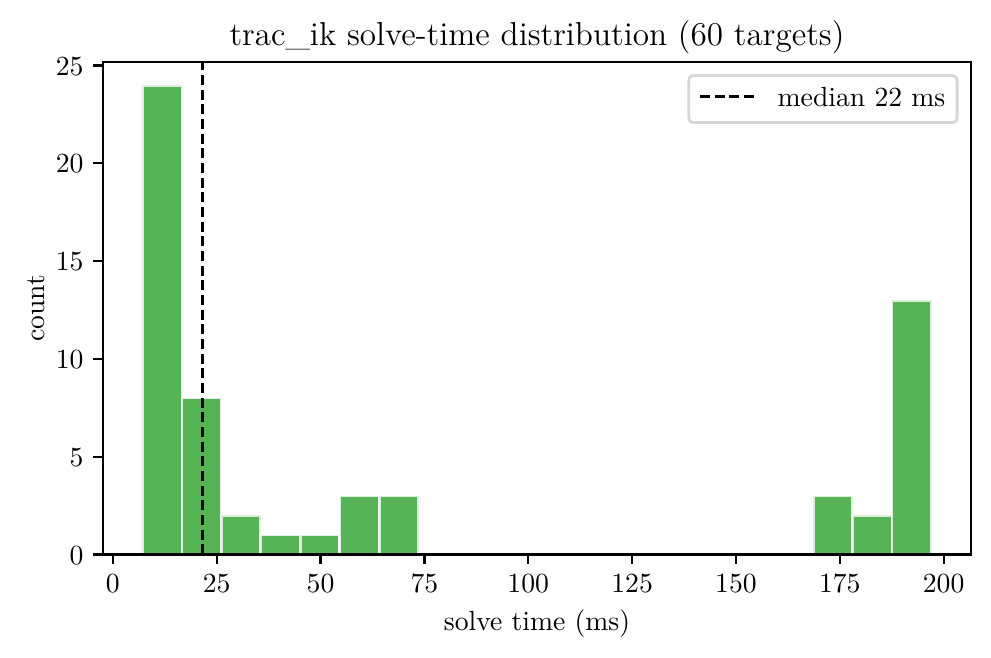

In [11]:
np.random.seed(11)
trac_times = []
for _ in range(60):
    T = sm.forward_kinematics(np.random.uniform(lims[:, 0], lims[:, 1]), frame='space')
    out, ms = solve_time(lambda: sm.trac_ik(T, theta0=HOME, timeout=0.2))
    trac_times.append(ms)

plt = setup_pgf()
fig, ax = plt.subplots(figsize=(5.6, 3.2))
ax.hist(trac_times, bins=20, color='tab:green', alpha=0.8, edgecolor='white')
ax.axvline(np.median(trac_times), color='black', ls='--', lw=1,
           label='median %.0f ms' % np.median(trac_times))
ax.set_xlabel('solve time (ms)'); ax.set_ylabel('count')
ax.set_title('trac_ik solve-time distribution (%d targets)' % len(trac_times))
ax.legend()
embed_pgf_fig(fig, name="trac_ik_timing")

## 6. One pose, many solutions

The Panda is **redundant** (7 joints, 6-D task), so a reachable pose has a whole 1-parameter family of joint solutions — the null-space self-motion from notebook 03. Inverse kinematics returns *one* of them, and which one depends on the seed. Solving for `q_target`'s pose starting from `HOME` lands a valid configuration that reaches the same pose with a **different elbow**.

In [12]:
theta_alt, ok, _ = sm.iterative_inverse_kinematics(T_d, HOME, max_iterations=4000)
T_alt = sm.forward_kinematics(theta_alt, frame='space')

# Same pose as q_target ...
assert ok and np.allclose(T_alt[:3, 3], T_d[:3, 3], atol=1e-3)
assert np.allclose(T_alt[:3, :3], T_d[:3, :3], atol=1e-2)
# ... reached by a genuinely different joint vector.
joint_gap = np.abs(theta_alt - q_target)
print("same end-effector pose, different joints:")
print("  max per-joint difference:", round(np.degrees(joint_gap.max()), 1), "deg")
assert joint_gap.max() > np.radians(5)         # not just a copy of q_target

same end-effector pose, different joints:
  max per-joint difference: 13.4 deg


## 7. When the target is out of reach

Not every pose is reachable. A good solver should **fail honestly** rather than return garbage. Pushing the target 1.5 m past the Panda's reach, `iterative_inverse_kinematics` reports `success=False` and leaves the arm at its closest approach. For hard-but-reachable poses, `robust_inverse_kinematics` retries from multiple seeds and reports which strategy won.

In [13]:
T_far = T_d.copy(); T_far[0, 3] += 1.5                 # shove it well outside the workspace
theta_f, ok_f, _ = sm.iterative_inverse_kinematics(T_far, HOME, max_iterations=1500)
T_f = sm.forward_kinematics(theta_f, frame='space')
print("unreachable target: success=%s, residual = %.2f m (honest failure)"
      % (ok_f, np.linalg.norm(T_f[:3, 3] - T_far[:3, 3])))
assert not ok_f                                        # correctly reports failure

# Multi-start robust solver on the reachable pose: returns the winning strategy.
theta_r, ok_r, iters_r, strategy = sm.robust_inverse_kinematics(T_d, max_attempts=10)
T_r = sm.forward_kinematics(theta_r, frame='space')
print("robust IK: success=%s via '%s' strategy, position error = %.2e m"
      % (ok_r, strategy, np.linalg.norm(T_r[:3, 3] - T_d[:3, 3])))
assert ok_r

unreachable target: success=False, residual = 0.92 m (honest failure)


robust IK: success=True via 'midpoint' strategy, position error = 8.07e-05 m


## 8. Seeing the solution

Finally, the payoff: load the meshed Panda into ManipulaPy's PyBullet simulation (headless, as in notebooks 02–03), pose it at the IK solution, and mark the target. The fingertip sits on the marker — the joint angles we solved for put the end-effector exactly where we asked.

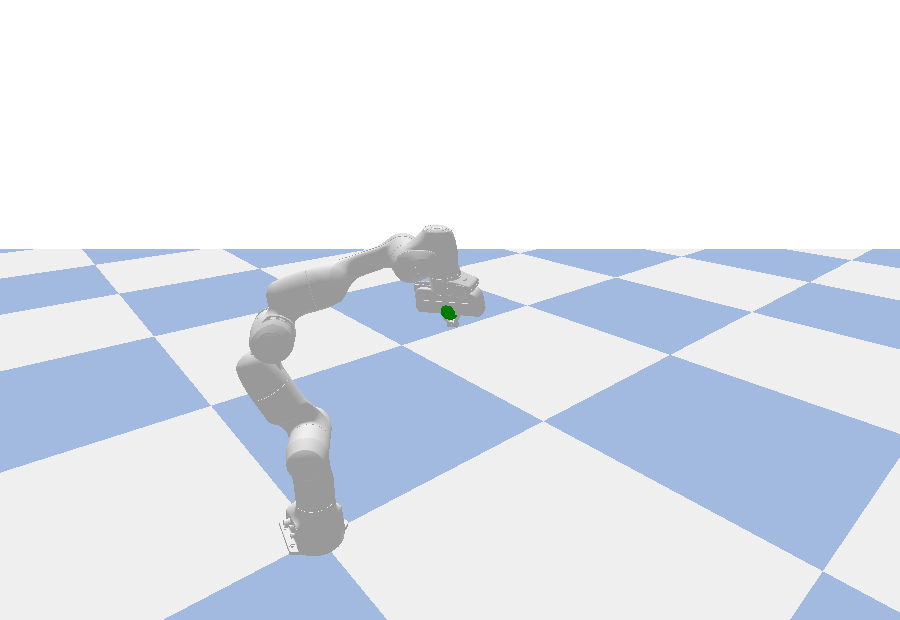

In [14]:
import logging
os.environ.setdefault("MANIPULAPY_PYBULLET_CONNECT", "DIRECT")  # headless; remove to watch in a GUI
from helpers import panda_pybullet_urdf, sim_snapshot, quiet_pybullet
from ManipulaPy.sim import Simulation
import pybullet as p

with quiet_pybullet():
    sim = Simulation(panda_pybullet_urdf(), joint_limits())
# Simulation's logger defaults to DEBUG; keep the notebook output clean.
logging.getLogger("SimulationLogger").setLevel(logging.WARNING)

# Pose the arm at the IK solution; the two gripper joints (non-fixed) pad with 0.
for j, qj in zip(sim.non_fixed_joints, list(theta) + [0.0, 0.0]):
    p.resetJointState(sim.robot_id, j, qj)

# Drop a green marker at the target end-effector position.
target_xyz = T_d[:3, 3]
marker = p.createVisualShape(p.GEOM_SPHERE, radius=0.03, rgbaColor=[0, 0.8, 0, 1])
p.createMultiBody(baseMass=0, baseVisualShapeIndex=marker, basePosition=list(target_xyz))
img = sim_snapshot("sim_ik_solution", target=tuple(target_xyz), distance=1.5, yaw=50, pitch=-20)
sim.disconnect_simulation()
img

## Smoke test

Asserts the key invariants of this notebook in one cell.

In [15]:
sm2, _ = load_panda(); sm2.joint_limits = joint_limits()
T_goal = sm2.forward_kinematics(HOME, frame='space')
# Library IK recovers a perturbed seed.
theta_s, ok_s, it_s = sm2.iterative_inverse_kinematics(T_goal, HOME + 0.2, max_iterations=2000)
assert ok_s, f'IK failed after {it_s} iterations'
T_check = sm2.forward_kinematics(theta_s, frame='space')
assert np.allclose(T_check[:3, 3], T_goal[:3, 3], atol=1e-3)        # position recovered
assert np.allclose(T_check[:3, :3], T_goal[:3, :3], atol=1e-2)      # orientation recovered
# Hand-rolled Newton-Raphson agrees with the library at the end-effector.
theta_h, _ = newton_ik(T_goal, HOME + 0.2, lam=0.05)
assert np.allclose(sm2.forward_kinematics(theta_h)[:3, 3], T_goal[:3, 3], atol=1e-3)
# Unreachable target is reported as a failure.
T_bad = T_goal.copy(); T_bad[0, 3] += 1.5
_, ok_bad, _ = sm2.iterative_inverse_kinematics(T_bad, HOME, max_iterations=1000)
assert not ok_bad
print("nb04 inverse kinematics: smoke OK")

nb04 inverse kinematics: smoke OK


## Try it

1. Solve IK for the same pose `T_d` from three different random seeds (`np.random.uniform` within `joint_limits()`). Do you always land the same joint vector? Confirm each still reaches `T_d`.
2. Keep `newton_ik` at `lam=0` (pure Newton–Raphson) but start near a stretched-out (near-singular) configuration. Watch the step sizes blow up — then add a little damping and see it recover.
3. Take the redundant solution `theta_alt` and a null-space step from notebook 03; verify you can slide between IK solutions without moving the end-effector.

*Next up — notebook 05: **dynamics** — the mass matrix, Coriolis and gravity terms, and the inverse/forward-dynamics round trip.*

## References

1. K. M. Lynch and F. C. Park, *Modern Robotics: Mechanics, Planning, and Control*, Cambridge University Press, 2017. — Chapter 6, *Inverse Kinematics* (Newton–Raphson on the body twist, numerical IK).
2. S. R. Buss, *Introduction to Inverse Kinematics with Jacobian Transpose, Pseudoinverse and Damped Least Squares methods*, 2004. — The damped least-squares step used here.
3. B. Siciliano, L. Sciavicco, L. Villani, and G. Oriolo, *Robotics: Modelling, Planning and Control*, Springer, 2009. — Redundancy resolution.
4. ManipulaPy documentation — https://manipulapy.readthedocs.io/ · source — https://github.com/boelnasr/ManipulaPy
